In [1]:
import pandas as pd
import missingno as msno
import fancyimpute as fci
import matplotlib.pyplot as plt

data = pd.read_csv("../0_DataPreparation/data.csv")

<Axes: >

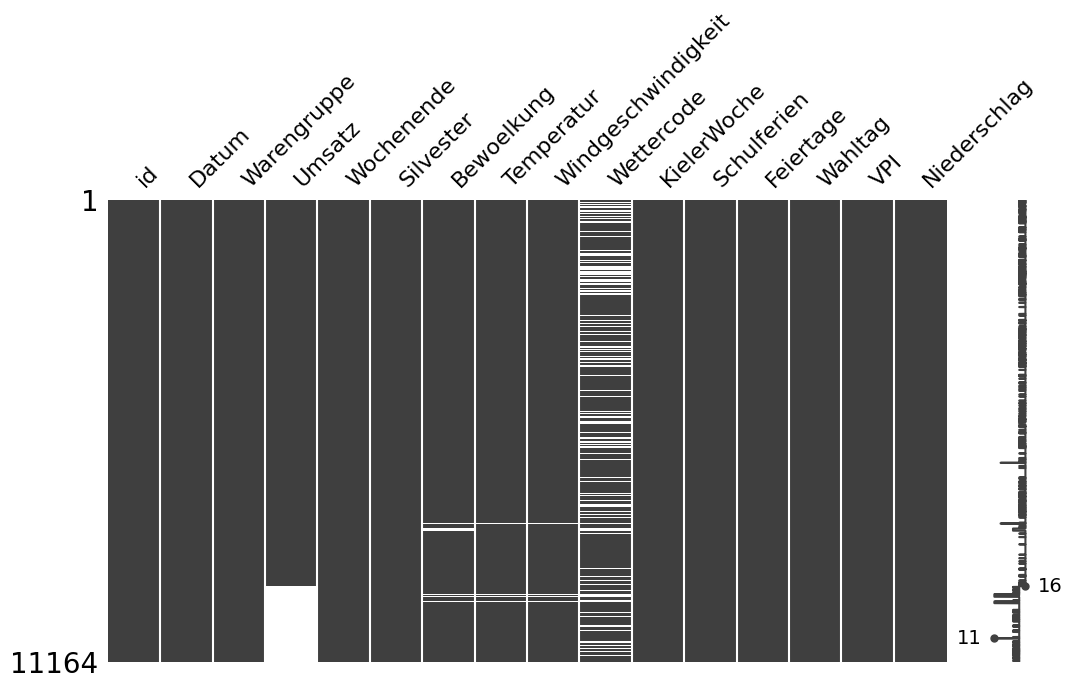

In [2]:
msno.matrix(data, figsize=(12, 6), sparkline=True)

<Axes: >

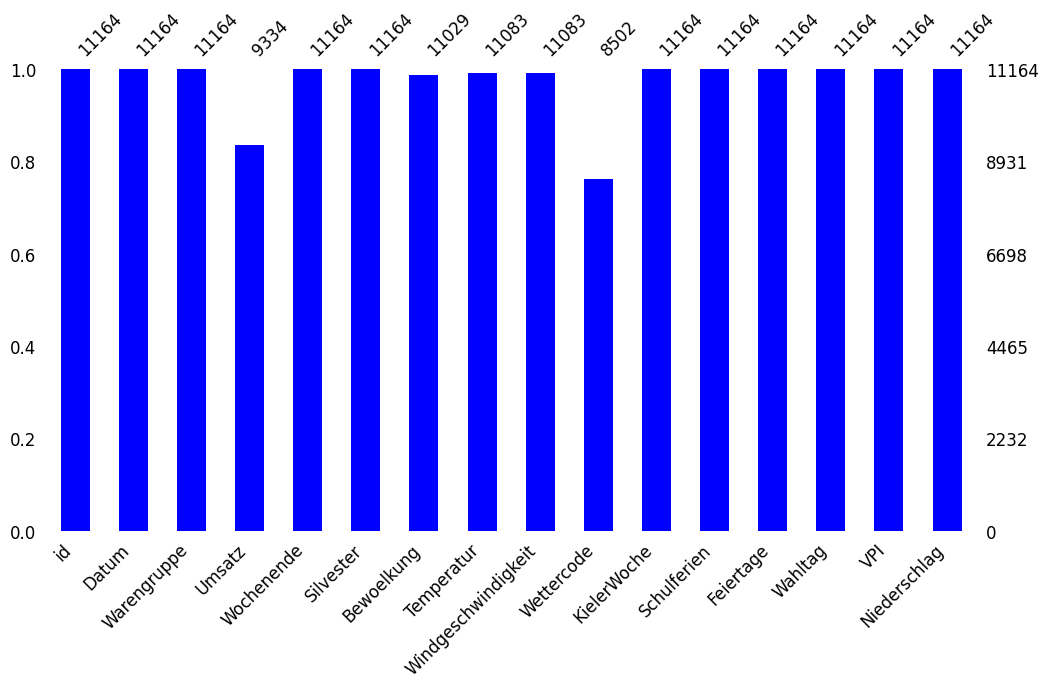

In [3]:
msno.bar(data, figsize=(12, 6), color="blue", fontsize=12)

<Axes: >

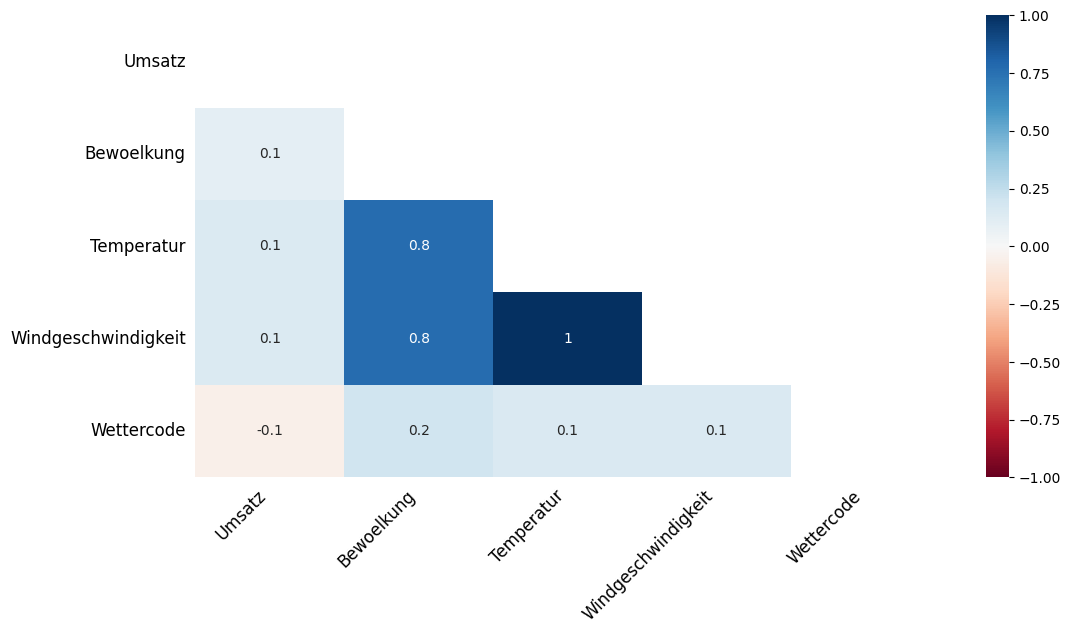

In [4]:
msno.heatmap(data, figsize=(12, 6), fontsize=12)

<Axes: >

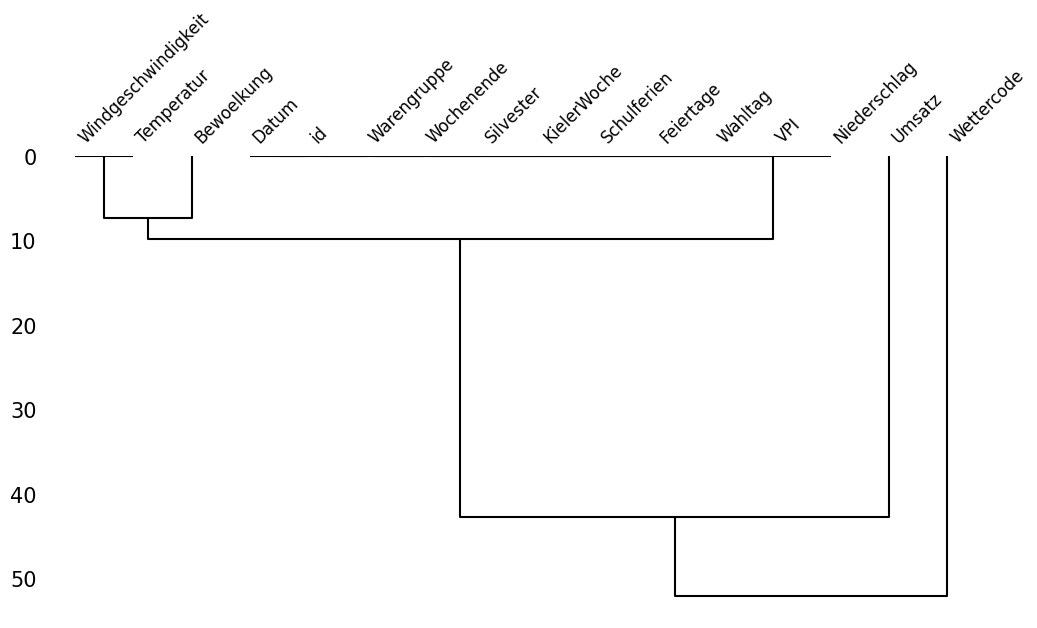

In [5]:
msno.dendrogram(data, figsize=(12, 6), fontsize=12)

<Axes: >

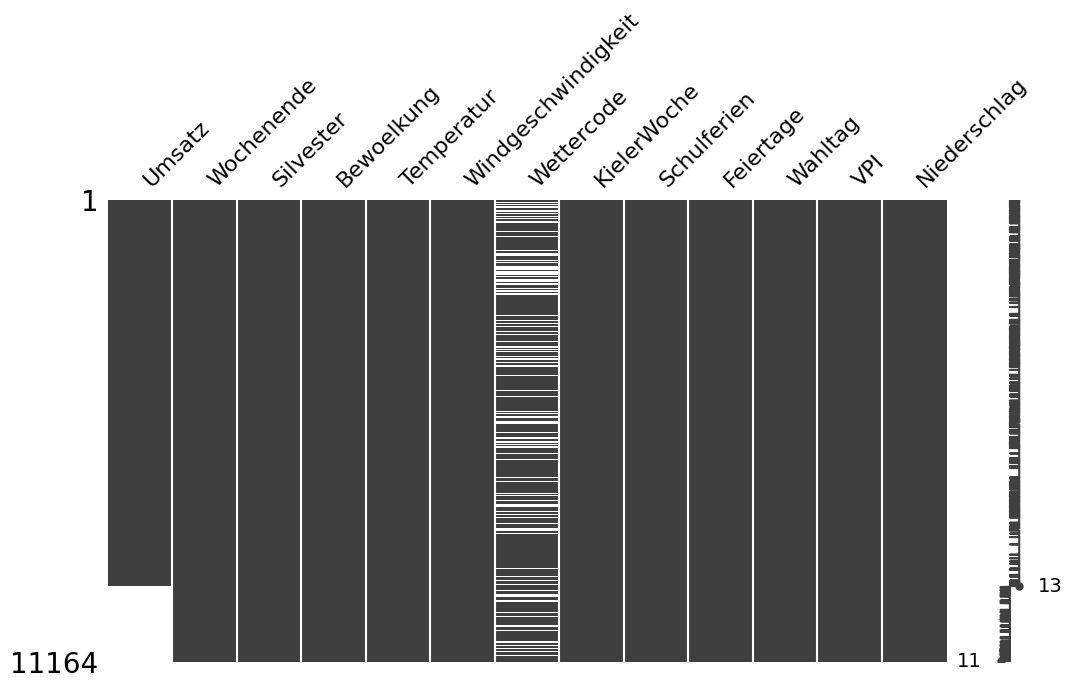

In [ ]:
cols = ['Bewoelkung', 'Temperatur', 'Windgeschwindigkeit']
nan_masks = {col: data[col].isna().astype(int) for col in cols}
# Use all columns to find neighbors, but only impute missing values in the specified columns
data_for_impute = data.drop(columns=['Datum', 'id', 'Warengruppe'])
imputed_all = fci.KNN().fit_transform(data_for_impute)
imputed_only_df = pd.DataFrame(imputed_all, columns=data_for_impute.columns)
imputed_df = data_for_impute.copy()
imputed_df[cols] = pd.DataFrame(imputed_all, columns=data_for_impute.columns)[cols]
msno.matrix(imputed_df, figsize=(12, 6), sparkline=True)

In [7]:
print("Correlation in original Data: ", data['Temperatur'].corr(data['Umsatz'], method='pearson'))
print("Correlation in imputed Data: ", imputed_df['Temperatur'].corr(imputed_df['Umsatz'], method='pearson'))

Correlation in original Data:  0.2229354367923913
Correlation in imputed Data:  0.22307929638485524


In [8]:
execute = True

if execute:
    imputed_df[['id', 'Datum', 'Warengruppe']] = data[['id', 'Datum', 'Warengruppe']]
    imputed_df['mask_Temperatur_Windgeschwindigkeit'] = nan_masks['Temperatur']
    imputed_df['mask_Bewoelkung'] = nan_masks['Bewoelkung']

<Axes: >

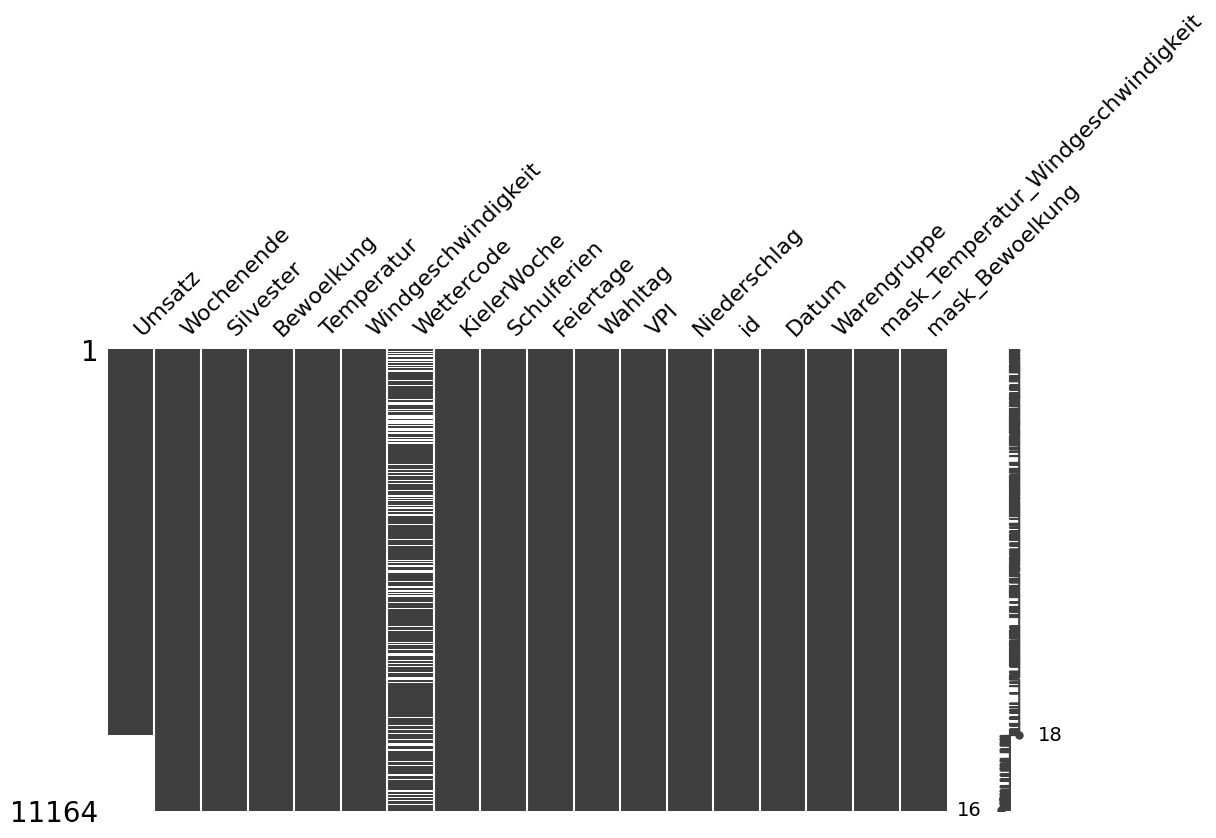

In [9]:
msno.matrix(imputed_df, figsize=(12, 6), sparkline=True)

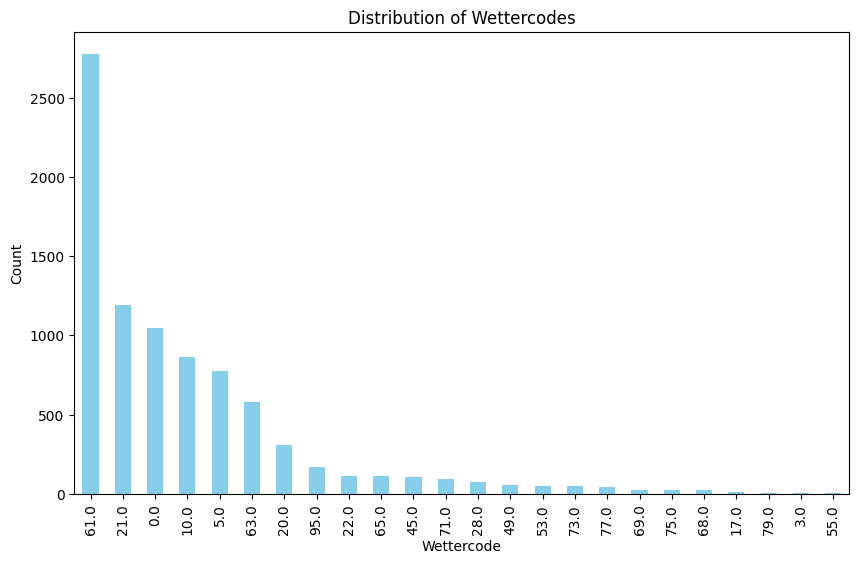

In [10]:
imputed_df['Wettercode'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.xlabel('Wettercode')
plt.ylabel('Count')
plt.title('Distribution of Wettercodes')
plt.show()

<Axes: >

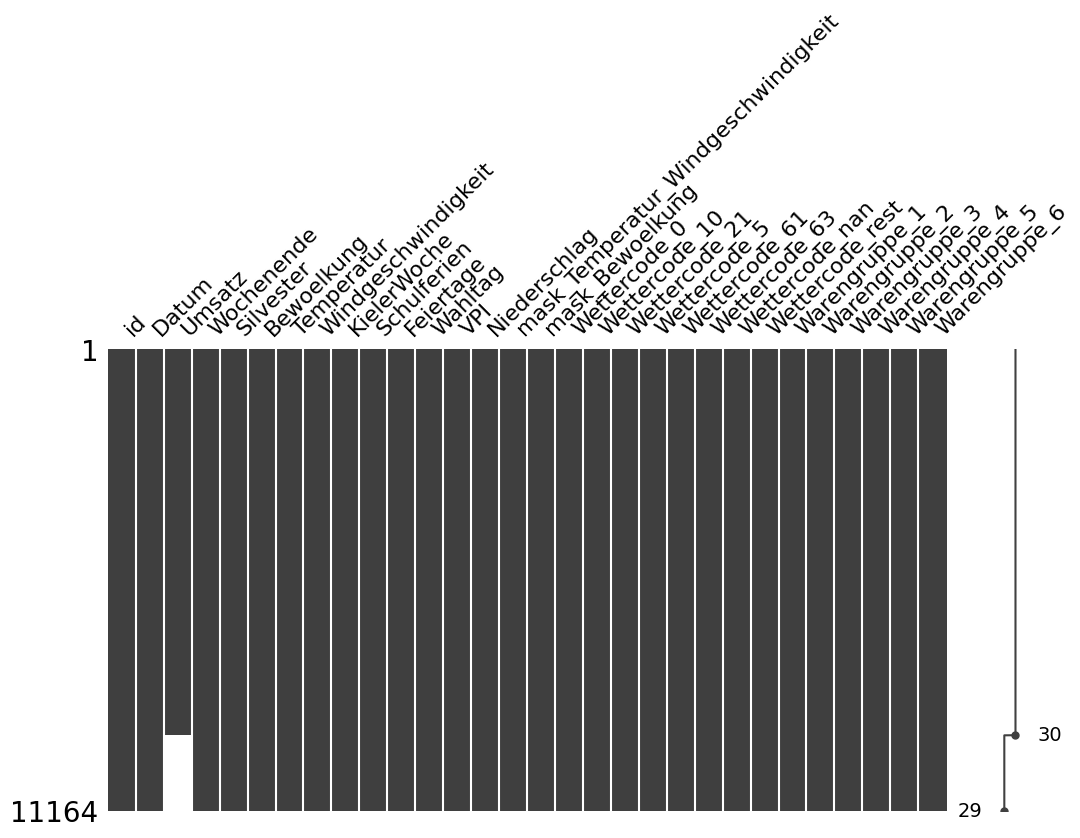

In [11]:
weathercode_map = {
    61: 'Wettercode_61',
    21: 'Wettercode_21',
    0: 'Wettercode_0',
    10: 'Wettercode_10',
    5: 'Wettercode_5',
    63: 'Wettercode_63'
}

def map_weathercode(val):
    if pd.isna(val):
        return 'Wettercode_nan'
    return weathercode_map.get(val, 'Wettercode_rest')

imputed_df['Wettercode_cat'] = imputed_df['Wettercode'].apply(map_weathercode)
weathercode_dummies = pd.get_dummies(imputed_df['Wettercode_cat']).astype(int)
imputed_df = pd.concat([imputed_df, weathercode_dummies], axis=1)

cols_first = ["id", "Datum", "Warengruppe"]
other_cols = [col for col in imputed_df.columns if col not in cols_first]
imputed_df = imputed_df[cols_first + other_cols]

# One-hot encode 'Warengruppe' and add to imputed_df
warengruppe_dummies = pd.get_dummies(imputed_df['Warengruppe'], prefix="Warengruppe", drop_first=False, dtype=int)
imputed_df = pd.concat([imputed_df, warengruppe_dummies], axis=1)

imputed_df = imputed_df.drop(columns=["Warengruppe", "Wettercode", "Wettercode_cat"])

msno.matrix(imputed_df, figsize=(12, 6), sparkline=True)

In [ ]:
imputed_df.to_csv("data_after_imputation.csv", index=False)